# Week 3


# Lecture 5: Gradient Descent

Today, we will focus on implementing gradient descent using basic `NumPy`. Gradient descent is a general-purpose optimization algorithm, but we will start by using it for some regression problems using some methods we have developed in the class so far.

### Some Ideas from Multivariate Calculus

First, we need just a few ideas from multivariate calculus. This is quite minimal, but you learn more details about these topics in sections 4.3 (partial derivatives), 4.6 (gradients), and 4.7 (multivariate optimization) of <a href="https://openstax.org/details/books/calculus-volume-3">*Calculus Volume 3*</a> by Strang.

The ideas we need for gradient descent include:

* If we have a differentiable function of several variables, like our loss function $L(\theta) = L(\theta_0, ..., \theta_d)$, we can define the **partial derivatives** with respect to each of these variables as

    $$L_{\theta_i}=\frac{\partial L}{\partial \theta_i}=\lim\limits_{h\to 0}\frac{L(\theta+he_i) - L(\theta)}{h},$$

    where $e_i$ is a $(d+1)$-vector with all 0s except for a 1 in the $i$th component.  Geometrically, this partial derivative is the slope of $L$ if we go in the direction of $e_i$.
    
* To **minimize a multivariable function** by hand, we need to find critical points, which are points $\theta$ where *all* partial derivatives are 0 and compare which ones give the lowest outputs. In numerical algorithms, must settle for approximations that are "nearly" critical points.
    
* If we put these partial derivatives into a vector of $d+1$ variables, we call that a **gradient**, which we denote
    
    $$
    \nabla L(\theta)
    =\begin{pmatrix}
    L_{\theta_0}(\theta) \\
    \vdots \\
    L_{\theta_d}(\theta)
    \end{pmatrix}
    $$
    
* The **directional derivative** of a function in the direction of a unit vector $u$ starting from a point $\theta$.

$$D_u L(\theta) = \lim\limits_{h\to 0}\frac{L(\theta+hu) - L(\theta)}{h},$$
    
which is the slope in the direction of the vector $u$. Since $L$ is differentiable, this directional derivative will be defined for all directions leaving from $\theta$. In 1D, there are just two directions: left of right. In 2D, we have directional derivatives at every angle in a circle around the point.

* A common theorem says the **directional derivative is maximized in the direction of the gradient** at each point, so the gradient gives the direction of the *steepest ascent* in the function $L$. Similarly, the direction of the *steepest descent* is $-\nabla L(\theta)$, the opposite direction.

### The Geometry of Gradient Descent

We will discuss the geometry of gradient-based methods in class, but let's discuss a general outline of how gradient descent works, setting aside the stochastic version for now. The goal of gradient descent is to approximately solve the minimization problem

$$\min\limits_{\theta}\,L(\theta)$$

by finding (approximate) critical values by making a guess for the location of a critical value, taking a small step in the opposite direction as the gradient, and repeating this over and over until, hopefully, we reach a minimum value.

The steps are:

0. Make a guess for the critical value -- $\theta^0$
1. Compute the gradient of $L$ at $\theta^0$
2. Take a small step to $\theta^1 = \theta^0 - \alpha\nabla L\left(\theta^0\right)$
3. Compute the gradient of $L$ at $\theta^1$
4. Take a small step to $\theta^2 = \theta^1 - \alpha\nabla L\left(\theta^1\right)$
5. (repeat until the gradient gets close to $(0, ..., 0)$)

This $\alpha>0$ is a number that will be used in the algorithm as a multiplier of the steps the method will take. This is called the **learning rate**.

This idea seems plausible from the calculus ideas above because we just keep switching directions and making a step in the direction of the steepest downward path--the opposite direction as the gradient--until we reach a good place. This is a "greedy" algorithm because it just picks the quickest step in each iteration, which is fast, but it is likely to land in the first minimum it finds, which may or may not be optimal.

If you had two parameters, $L$ would be like a 3D curved surface. A nice visual to have in mind is a rain drop falling on a huge leaf. The droplet of water will move in the steepest downward direction due to gravity--but this direction *changes* as the drip follows the contours of the leaf. This is what gradient descent does.

Will the drip land in the physically lowest altitude part of the leaf? Maybe, but maybe not. If the rain drop lands on the edge, it will probably just roll off the edge. If the leaf has a few different "sinks," different initial locations of the rain drop might cause it to land in these different ones, some of which have lower altitudes than others. Now, if there is heavy rain and lots of rain drops land on the leaf, we can be pretty sure *some* of them will reach the lowest-altitude sink.

From this analogy, you might get the idea that we can make several initial guesses and run it to be more confident we will find the global minimum and not just a local minimum.

In the end, if some of our initial guesses are good choices, the step size $\alpha$ is not too big or too small, and the loss function is pretty well-behaved, the method will converge approximately to a local minimum.

### Implementing Gradient Descent

Let's import some libraries then write a function for gradient descent.

In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

Gradient descent will need a few inputs:

* An explicit gradient function $\nabla L(\theta)$
* A starting parameter vector $\theta^0$
* A learning rate $\alpha$
* A small positive tolerance for deciding when the gradient is sufficiently close to zero
* A maximum number of iterations

Each model will supply the analytical gradient of its loss. This makes the update direct and efficient: every step uses the actual value of $\nabla L(\theta)$.


In [2]:
def gradient_descent(gradient_function, theta, alpha, tolerance, max_iterations):
    """Minimize a differentiable loss using its analytical gradient."""
    theta = np.array(theta, dtype=float)

    for iteration in range(max_iterations):
        gradient = gradient_function(theta)

        if np.linalg.norm(gradient) < tolerance:
            print('Gradient descent took', iteration, 'iterations to converge')
            print('The norm of the gradient is', np.linalg.norm(gradient))
            return theta

        theta -= alpha * gradient

    print('Gradient descent reached the maximum number of iterations')
    print('The norm of the gradient is', np.linalg.norm(gradient))
    return theta


### OLS by Gradient Descent

For labeled data $(x_{i1},\ldots,x_{id},y_i)$, our linear model is

$$f_\theta(x_i)=\theta_0+\sum_{j=1}^d\theta_jx_{ij}.$$

After adding a leading column of ones to the data matrix $X$, the model predictions are $X\theta$. We will minimize mean squared error,

$$L(\theta)=\frac{1}{n}\lVert X\theta-y\rVert_2^2.$$

Its analytical gradient is

$$\nabla L(\theta)=\frac{2}{n}X^T(X\theta-y).$$

This formula gives gradient descent everything it needs; the algorithm does not need to estimate derivatives from repeated loss evaluations. First, here is the exact OLS class from Week 1 for comparison.


In [3]:
class OrdinaryLeastSquaresExact:
        
    # fit the model to the data
    def fit(self, X, y):
        # save the training data
        self.data = np.hstack((np.ones([X.shape[0],1]), X))
        
        # save the training labels
        self.output = y
        
        # find the theta values that minimize the sum of squared errors
        X = self.data
        self.theta = np.linalg.inv(X.T @ X) @ X.T @ y
                
    # predict the output from input (testing) data
    def predict(self, X):
        # initialize an empty matrix to store the predicted outputs
        yPredicted = np.empty([X.shape[0],1])
        
        # append a column of ones at the beginning of X
        X = np.hstack((np.ones([X.shape[0],1]), X))
        
        # apply the function f with the values of theta from the fit function to each testing datapoint
        for row in range(X.shape[0]):
            yPredicted[row] = self.theta @ X[row,]
            
        return yPredicted

Next, we implement OLS using gradient descent. The model defines both its loss and its analytical gradient, then passes the gradient function to `gradient_descent`.


In [4]:
class OrdinaryLeastSquaresGradient:
    def fit(self, X, y, theta0, alpha, tolerance, max_iterations):
        n = X.shape[0]
        X = np.hstack((np.ones((n, 1)), X))

        loss = lambda theta: np.mean((X @ theta - y) ** 2)
        loss_gradient = lambda theta: (2 / n) * X.T @ (X @ theta - y)

        self.theta = gradient_descent(
            loss_gradient, theta0, alpha, tolerance, max_iterations
        )
        self.loss = loss(self.theta)
        return self

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        return X @ self.theta


### 1D Example (Revisited)

FOR THE GRADIENT-BASED ORDINARY LEAST SQUARES CODE
Gradient descent took 45461 iterations to converge
The norm of the gradient is 0.009999906613082001

The predicted y values are [1.90137017 2.40393186 2.90649354 3.40905522 2.40393186]
The real y values are [1 2 3 3 4]
The theta values are [-1.11399992  0.50256168]
The r^2 score is 0.28862840644169796
The mean absolute error is 0.6807863712781319 

FOR THE EXACT ORDINARY LEAST SQUARES CODE 

The predicted y values are [[1.84615385]
 [2.38461538]
 [2.92307692]
 [3.46153846]
 [2.38461538]]
The real y values are [1 2 3 3 4]
The theta values are [-1.38461538  0.53846154]
The r^2 score is 0.2899408284023671
The mean absolute error is 0.6769230769230786


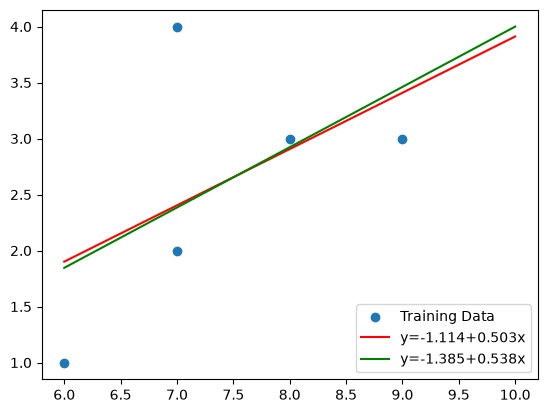

In [5]:
X = np.array([[6], [7], [8], [9], [7]])
y = np.array([1, 2, 3, 3, 4])

print('FOR THE GRADIENT-BASED ORDINARY LEAST SQUARES CODE')

# instantiate an OLS (gradient) object, fit to data, predict data
model = OrdinaryLeastSquaresGradient()
model.fit(X, y, [0, 0], alpha = 0.001, tolerance = 0.01, max_iterations = 100000)
predictions = model.predict(X)

# print the predictions
print('\nThe predicted y values are', predictions)

# print the real y values
print('The real y values are', y)

# print the theta values
parameters = model.theta
print('The theta values are', parameters)

# plot the training points
plt.scatter(X, y, label = 'Training Data')

# plot the fitted model with the training data
xModel = np.linspace(6,10,100)
yModel = parameters[0] + parameters[1]*xModel
lineFormula = 'y={:.3f}+{:.3f}x'.format(parameters[0], parameters[1])
plt.plot(xModel, yModel, 'r', label = lineFormula)

# add a legend
plt.legend()

# return quality metrics
print('The r^2 score is', r2_score(y, predictions))
print('The mean absolute error is', mean_absolute_error(y, predictions),'\n')

###################################################################################

print('FOR THE EXACT ORDINARY LEAST SQUARES CODE \n')

# instantiate an OLS (exact) object, fit to data, predict data
model = OrdinaryLeastSquaresExact()
model.fit(X,y)
predictions = model.predict(X)

# print the predictions
print('The predicted y values are', predictions)

# print the real y values
print('The real y values are', y)

# print the theta values
parameters = model.theta
print('The theta values are', parameters)

# plot the fitted model with the training data
xModel = np.linspace(6,10,100)
yModel = parameters[0] + parameters[1]*xModel
lineFormula = 'y={:.3f}+{:.3f}x'.format(parameters[0], parameters[1])
plt.plot(xModel, yModel, 'g', label = lineFormula)

# add a legend
plt.legend()

# return quality metrics
print('The r^2 score is', r2_score(y, predictions))
print('The mean absolute error is', mean_absolute_error(y, predictions))

## 2D Example (Revisited)

In [6]:
trainX = np.array([[2, 2], [2, 3], [5, 6], [6, 7], [9, 10]])
trainY = np.array([3, 13, 19, 29, 35])

testX = np.array([[2, 1], [4, 5], [6, 5], [8, 9]])
testY = np.array([9, 15, 25, 31])

print('FOR THE GRADIENT-BASED ORDINARY LEAST SQUARES CODE \n')

# instantiate an OLS model
model = OrdinaryLeastSquaresGradient()

# fit the model to the training data (find the theta parameters)
model.fit(trainX, trainY, [0, 0, 0], alpha = 0.001, tolerance = 0.01, max_iterations = 100000)

# return the predicted outputs for the datapoints in the training set
trainPredictions = model.predict(trainX)

# print the coefficient of determination r^2
print('The r^2 score is', r2_score(trainY, trainPredictions))

# print quality metrics
print('The mean absolute error on the training set is', mean_absolute_error(trainY, trainPredictions))

# return the predicted outputs for the datapoints in the test set
predictions = model.predict(testX)

# print the predictions
print('The predicted y values for the test set are', predictions)

# print the real y values
print('The real y values for the test set are', testY)

# print the theta values
thetaApprox = model.theta
print('The theta values are', thetaApprox)

# print quality metrics
print('The mean absolute error on the test set is', mean_absolute_error(testY, predictions), '\n')

##############################################################################################

print('FOR THE EXACT ORDINARY LEAST SQUARES CODE \n')

# instantiate an OLS model
model = OrdinaryLeastSquaresExact()

# fit the model to the training data (find the theta parameters)
model.fit(trainX, trainY)

# return the predicted outputs for the datapoints in the training set
trainPredictions = model.predict(trainX)

# print the coefficient of determination r^2
print('The r^2 score is', r2_score(trainY, trainPredictions))

# print quality metrics
print('The mean absolute error on the training set is', mean_absolute_error(trainY, trainPredictions))

# return the predicted outputs for the datapoints in the test set
predictions = model.predict(testX)

# print the predictions
print('The predicted y values for the test set are', predictions)

# print the real y values
print('The real y values for the test set are', testY)

# print the theta values
thetaExact = model.theta
print('The theta values are', thetaExact)

# print quality metrics
print('The mean absolute error on the test set is', mean_absolute_error(testY, predictions))

FOR THE GRADIENT-BASED ORDINARY LEAST SQUARES CODE 

Gradient descent took 48479 iterations to converge
The norm of the gradient is 0.009999291440479082
The r^2 score is 0.9642640170040087
The mean absolute error on the training set is 1.5500012222663557
The predicted y values for the test set are [-6.41219656 19.06443704  6.72691214 32.20354573]
The real y values for the test set are [ 9 15 25 31]
The theta values are [-3.52821129 -6.16876245  9.45353962]
The mean absolute error on the test set is 9.73831679830663 

FOR THE EXACT ORDINARY LEAST SQUARES CODE 

The r^2 score is 0.9642679900744417
The mean absolute error on the training set is 1.5360000000001235
The predicted y values for the test set are [[-6.52]
 [19.08]
 [ 6.6 ]
 [32.2 ]]
The real y values for the test set are [ 9 15 25 31]
The theta values are [-3.56 -6.24  9.52]
The mean absolute error on the test set is 9.799999999999963


## Example: High School Graduate Rates in the US (Revisited)

In [7]:
# import the data from the csv file to an numpy array
data = pd.read_csv('../data/US_State_Data.csv', sep=',').to_numpy()

X = np.array(data[:,1:8], dtype=float)
y = np.array(data[:,8], dtype=float)

# split the data into training and test sets
(trainX, testX, trainY, testY) = train_test_split(X, y, test_size = 0.25, random_state = 1)

# standardize the data
trainX = scale(trainX)
testX = scale(testX)

print('FOR THE GRADIENT-BASED ORDINARY LEAST SQUARES CODE')

# instantiate an OLS model
model = OrdinaryLeastSquaresGradient()

# fit the model to the training data (find the theta parameters)
model.fit(trainX, trainY, [0, 0, 0, 0, 0, 0, 0, 0], alpha = 0.001, tolerance = 0.01, max_iterations = 100000)

# return the predicted outputs for the datapoints in the training set
trainPredictions = model.predict(trainX)

# print the coefficient of determination r^2
print('\nThe r^2 score is', r2_score(trainY, trainPredictions))

# print quality metrics
print('The mean absolute error on the training set is', mean_absolute_error(trainY, trainPredictions))

# return the predicted outputs for the datapoints in the test set
predictions = model.predict(testX)

# print the predictions
print('The predicted y values for the test set are', np.round(predictions,0))

# print the real y values
print('The real y values for the test set are     ', testY)

# print the theta values
print('The theta values are', model.theta)

# print quality metrics
print('The mean absolute error on the test set is', mean_absolute_error(testY, predictions), '\n')

##################################################################

print('FOR THE EXACT ORDINARY LEAST SQUARES CODE \n')

# instantiate an OLS model
model = OrdinaryLeastSquaresExact()

# fit the model to the training data (find the theta parameters)
model.fit(trainX, trainY)

# return the predicted outputs for the datapoints in the training set
trainPredictions = model.predict(trainX)

# print the coefficient of determination r^2
print('The r^2 score is', r2_score(trainY, trainPredictions))

# print quality metrics
print('The mean absolute error on the training set is', mean_absolute_error(trainY, trainPredictions))

# return the predicted outputs for the datapoints in the test set
predictions = model.predict(testX)

# print the predictions
print('The predicted y values for the test set are', np.round(predictions,0))

# print the real y values
print('The real y values for the test set are     ', testY)

# print the theta values
print('The theta values are', model.theta)

# print quality metrics
print('The mean absolute error on the test set is', mean_absolute_error(testY, predictions))

FOR THE GRADIENT-BASED ORDINARY LEAST SQUARES CODE
Gradient descent took 17216 iterations to converge
The norm of the gradient is 0.00999865308237462

The r^2 score is 0.4035189164520572
The mean absolute error on the training set is 3.6673677332708845
The predicted y values for the test set are [82. 80. 89. 85. 81. 81. 85. 90. 78. 84. 83. 80. 83.]
The real y values for the test set are      [70. 83. 83. 81. 76. 87. 89. 89. 78. 78. 84. 80. 79.]
The theta values are [82.97297297 -3.73940089  0.77461033 -1.78207287 -1.16883484 -1.61334957
  2.11322409  0.85215872]
The mean absolute error on the test set is 3.995868664159337 

FOR THE EXACT ORDINARY LEAST SQUARES CODE 

The r^2 score is 0.4035248263372675
The mean absolute error on the training set is 3.6671426682489634
The predicted y values for the test set are [[82.]
 [80.]
 [89.]
 [85.]
 [81.]
 [81.]
 [85.]
 [90.]
 [78.]
 [84.]
 [83.]
 [80.]
 [83.]]
The real y values for the test set are      [70. 83. 83. 81. 76. 87. 89. 89. 78. 78. 8

## Comments on Gradient Descent

* The gradient-based and exact OLS methods produce nearly identical results in these examples.

* The learning rate $\alpha$ controls the size of each update, while the tolerance determines when the gradient is close enough to zero to stop.

* Each model supplies an explicit analytical gradient whose input is the parameter vector $\theta$.

* For mean squared error, one matrix expression computes all partial derivatives at once: $\nabla L(\theta)=\frac{2}{n}X^T(X\theta-y)$.

* Gradient descent and related methods are central to fitting many machine-learning models, including linear models and neural networks.


### Gradient Descent for Kernel Regression and Smoothing

For a query point $x_0$, kernel regression assigns each training example a weight and stores those weights in a diagonal matrix $K(x_0)$. We minimize the weighted squared-error loss

$$L(\theta)=(X\theta-y)^T K(x_0)(X\theta-y).$$

Because $K(x_0)$ is symmetric, its analytical gradient is

$$\nabla L(\theta)=2X^T K(x_0)(X\theta-y).$$

The same `gradient_descent` function can therefore fit the local linear model once we supply this gradient.


In [8]:
def GaussianKernel(x0, x, lam):
    return (1 / lam) * np.exp(-np.linalg.norm(x0 - x) ** 2 / (2 * lam ** 2))


class KernelRegressionGradient:
    def __init__(self, kernel_function, lam, fit_intercept=True):
        self.kernel_function = kernel_function
        self.fit_intercept = fit_intercept
        self.lam = lam

    def predict(self, x0, X, y, theta0, alpha, tolerance, max_iterations):
        n = X.shape[0]

        if self.fit_intercept:
            X = np.hstack((np.ones((n, 1)), X))

        kernel_weights = np.array([
            self.kernel_function(x0, row, self.lam) for row in X
        ])
        K = np.diag(kernel_weights)

        loss_gradient = lambda theta: 2 * X.T @ K @ (X @ theta - y)
        self.theta = gradient_descent(
            loss_gradient, theta0, alpha, tolerance, max_iterations
        )

        query = np.array([1, float(x0)]) if self.fit_intercept else np.atleast_1d(x0)
        return query @ self.theta


In [9]:
# read the shampoo sales dataset
data = pd.read_csv('../data/shampoo.csv')

# save the targets
y = data['Sales'].to_numpy()

# make a column vector of 0s with n elements
X = np.zeros([y.shape[0], 1])

# convert the vector to (0, 1, 2, ..., n)
X[:,0] = [i for i in range(y.shape[0])]

X = scale(X)

# split the data into train and test sets
(trainX, testX, trainY, testY) = train_test_split(X, y, test_size = 0.25, random_state = 1)

Gradient descent took 68718 iterations to converge
The norm of the gradient is 0.009999677726973116
Gradient descent took 37563 iterations to converge
The norm of the gradient is 0.009998714150167832
Gradient descent took 21206 iterations to converge
The norm of the gradient is 0.009997946024704355
Gradient descent took 12381 iterations to converge
The norm of the gradient is 0.00999729115629408
Gradient descent took 7484 iterations to converge
The norm of the gradient is 0.009989603862232107
Gradient descent took 4688 iterations to converge
The norm of the gradient is 0.00998198232625957
Gradient descent took 3046 iterations to converge
The norm of the gradient is 0.00999499196677278
Gradient descent took 2057 iterations to converge
The norm of the gradient is 0.00996986619082391
Gradient descent took 1446 iterations to converge
The norm of the gradient is 0.009987662160971977
Gradient descent took 1063 iterations to converge
The norm of the gradient is 0.009967845831088876
Gradient d

/tmp/ipykernel_34724/1165281318.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query = np.array([1, float(x0)]) if self.fit_intercept else np.atleast_1d(x0)


Gradient descent took 21130 iterations to converge
The norm of the gradient is 0.00999690811843546
Gradient descent took 39931 iterations to converge
The norm of the gradient is 0.00999929753866224
Gradient descent took 1682 iterations to converge
The norm of the gradient is 0.009941041851886058
Gradient descent took 4037 iterations to converge
The norm of the gradient is 0.009992018592059592
Gradient descent took 1869 iterations to converge
The norm of the gradient is 0.009983032285294518
Gradient descent took 559 iterations to converge
The norm of the gradient is 0.00987541939226164
Gradient descent took 1581 iterations to converge
The norm of the gradient is 0.009936105211777494
Gradient descent took 694 iterations to converge
The norm of the gradient is 0.009831755967165217
Gradient descent took 867 iterations to converge
The norm of the gradient is 0.009980947221620962
Gradient descent took 11654 iterations to converge
The norm of the gradient is 0.009995841031992388
Gradient desc

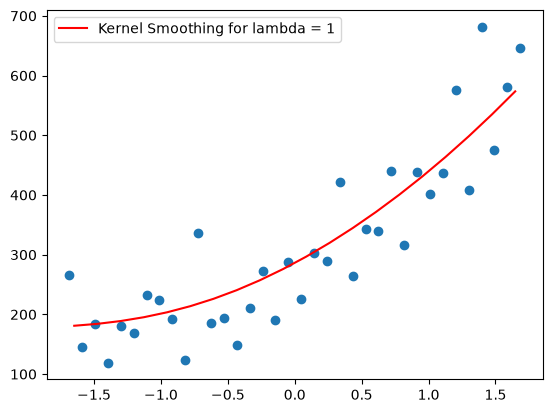

In [10]:
lam = 1

model = KernelRegressionGradient(GaussianKernel, lam)

# compute the model coordinates
xModel = scale([i for i in range(20)])
yModel = [model.predict(i, trainX, trainY, [0, 0], alpha = 0.001, tolerance = 0.01, max_iterations = 100000) for i in xModel]

# plot the model
label = 'Kernel Smoothing for lambda = ' + str(np.round(lam, 2))
plt.scatter(X, y)
plt.plot(xModel, yModel, 'r', label = label)
plt.legend()
    
# apply the functions to the test data and predict with the model
trainPredictions = [model.predict(i, trainX, trainY, [0, 0], alpha = 0.001, tolerance = 0.01, max_iterations = 100000) for i in trainX]
testPredictions = [model.predict(i, trainX, trainY, [0, 0], alpha = 0.001, tolerance = 0.01, max_iterations = 100000) for i in testX]
    
# compute the training and test mean absolute error
trainError = mean_absolute_error(trainY, trainPredictions)
testError = mean_absolute_error(testY, testPredictions)
    
# return quality metrics
print('lambda:', np.round(lam, 3), '\t\tr^2:', np.round(r2_score(trainY, trainPredictions), 3),
      '\t\ttrain MAE:', np.round(trainError, 3), '\t\ttest MAE:', np.round(testError, 3))

The analytical gradient keeps each local fit compact enough to repeat across several bandwidth values. The next example compares training and testing error as $\lambda$ changes.


In [ ]:
lamValues = np.linspace(0.6, 2, 15)

M = lamValues.shape[0]

# allow multiple plots
fig, axes = plt.subplots(nrows = M + 1, figsize = (10, 4*M))

trainMAE = []
testMAE = []

for (j, lam) in enumerate(lamValues):
    print(j)
    model = KernelRegressionGradient(GaussianKernel, lam)

    # compute the model coordinates
    xModel = scale([i for i in range(20)])
    yModel = [model.predict(i, trainX, trainY, [0, 0], alpha = 0.001, tolerance = 0.01,
                            max_iterations = 100000) for i in xModel]

    # plot the model
    label = 'Kernel Smoothing for lambda = ' + str(np.round(lam, 2))
    axes[j].scatter(X, y)
    axes[j].plot(xModel, yModel, 'r', label = label)
    axes[j].legend()
    
    # apply the functions to the test data and predict with the model
    trainPredictions = [model.predict(i, trainX, trainY, [0, 0], alpha = 0.001,
                                      tolerance = 0.01, max_iterations = 100000) for i in trainX]
    testPredictions = [model.predict(i, trainX, trainY, [0, 0], alpha = 0.001,
                                     tolerance = 0.01, max_iterations = 100000) for i in testX]
    
    # compute the training and test mean absolute error
    trainError = mean_absolute_error(trainY, trainPredictions)
    testError = mean_absolute_error(testY, testPredictions)
    
    # save the training and test mean absolute error
    trainMAE.append(trainError)
    testMAE.append(testError)

    # return quality metrics
    print('lambda:', np.round(lam, 3), '\t\tr^2:', np.round(r2_score(trainY, trainPredictions), 3),
          '\t\ttrain MAE:', np.round(trainError, 3), '\t\ttest MAE:', np.round(testError, 3))
    
# plot the errors
axes[M].plot(range(M), trainMAE, label = 'Training Mean Absolute Error')
axes[M].plot(range(M), testMAE, label = 'Testing Mean Absolute Error')
axes[M].legend()

0
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.32264627643270616
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.42835603626835117
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.279371892373567
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.6230474287473653
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.3662758423591506
Gradient descent took 94867 iterations to converge
The norm of the gradient is 0.009999873918139475
Gradient descent took 39319 iterations to converge
The norm of the gradient is 0.009998802690032648
Gradient descent took 17416 iterations to converge
The norm of the gradient is 0.009998393583990609
Gradient descent took 8292 iterations to converge
The norm of the gradient is 0.009996390510105235
Gradient descent took 4318 iterations to converge
The norm of the gradien

/tmp/ipykernel_34724/1165281318.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query = np.array([1, float(x0)]) if self.fit_intercept else np.atleast_1d(x0)


Gradient descent took 1750 iterations to converge
The norm of the gradient is 0.009974404755378707
Gradient descent took 5560 iterations to converge
The norm of the gradient is 0.009994646152262275
Gradient descent took 998 iterations to converge
The norm of the gradient is 0.009979661195809935
Gradient descent took 1350 iterations to converge
The norm of the gradient is 0.009985143331528043
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.281236589560397
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.4485242932573177
Gradient descent took 11407 iterations to converge
The norm of the gradient is 0.009995749867186135
Gradient descent took 69994 iterations to converge
The norm of the gradient is 0.009999872438899243
Gradient descent took 2719 iterations to converge
The norm of the gradient is 0.009993828099454047
Gradient descent took 1413 iterations to converge
The norm of the gradient is 0.00998692671567371

/tmp/ipykernel_34724/1165281318.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query = np.array([1, float(x0)]) if self.fit_intercept else np.atleast_1d(x0)


Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.5783617866215284
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.5179724689299875
Gradient descent took 5254 iterations to converge
The norm of the gradient is 0.009992057170058305
Gradient descent took 22870 iterations to converge
The norm of the gradient is 0.009999697117743952
Gradient descent took 3733 iterations to converge
The norm of the gradient is 0.009992238793940974
Gradient descent took 963 iterations to converge
The norm of the gradient is 0.009918360916282504
Gradient descent took 3008 iterations to converge
The norm of the gradient is 0.009998367754921758
Gradient descent took 1215 iterations to converge
The norm of the gradient is 0.00998104207816453
Gradient descent took 1720 iterations to converge
The norm of the gradient is 0.009963718718700335
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.0520091377

...

Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.012234621235867773
Gradient descent reached the maximum number of iterations
The norm of the gradient is 0.38047204066567
Gradient descent took 3121 iterations to converge
The norm of the gradient is 0.009989845049456481
Gradient descent took 10579 iterations to converge
The norm of the gradient is 0.009994744763541907
Gradient descent took 2963 iterations to converge
The norm of the gradient is 0.009984571533853143
Gradient descent took 730 iterations to converge
The norm of the gradient is 0.009874793836629998
Gradient descent took 2413 iterations to converge
The norm of the gradient is 0.009989155782420928
Gradient descent took 927 iterations to converge
The norm of the gradient is 0.009935993996133893
Gradient descent took 1240 iterations to converge
The norm of the gradient is 0.00998037184947285
Gradient descent took 45563 iterations to converge
The norm of the gradient is 0.00999874796533958


/tmp/ipykernel_34724/1165281318.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query = np.array([1, float(x0)]) if self.fit_intercept else np.atleast_1d(x0)


Gradient descent took 41871 iterations to converge
The norm of the gradient is 0.009998170892973264
Gradient descent took 87657 iterations to converge
The norm of the gradient is 0.009999216594482668
Gradient descent took 2174 iterations to converge
The norm of the gradient is 0.009949831979111695
Gradient descent took 6079 iterations to converge
The norm of the gradient is 0.009983198567078785
Gradient descent took 2327 iterations to converge
The norm of the gradient is 0.009977055837576432
Gradient descent took 611 iterations to converge
The norm of the gradient is 0.009891063883332636
Gradient descent took 1930 iterations to converge
The norm of the gradient is 0.009982764741922404
Gradient descent took 776 iterations to converge
The norm of the gradient is 0.0099556949796947
Gradient descent took 999 iterations to converge
The norm of the gradient is 0.009992206320227936
Gradient descent took 20953 iterations to converge
The norm of the gradient is 0.009996596986067323
Gradient des

/tmp/ipykernel_34724/1165281318.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query = np.array([1, float(x0)]) if self.fit_intercept else np.atleast_1d(x0)


Gradient descent took 21130 iterations to converge
The norm of the gradient is 0.00999690811843546
Gradient descent took 39931 iterations to converge
The norm of the gradient is 0.00999929753866224
Gradient descent took 1682 iterations to converge
The norm of the gradient is 0.009941041851886058
Gradient descent took 4037 iterations to converge
The norm of the gradient is 0.009992018592059592
Gradient descent took 1869 iterations to converge
The norm of the gradient is 0.009983032285294518
Gradient descent took 559 iterations to converge
The norm of the gradient is 0.00987541939226164
Gradient descent took 1581 iterations to converge
The norm of the gradient is 0.009936105211777494
Gradient descent took 694 iterations to converge
The norm of the gradient is 0.009831755967165217
Gradient descent took 867 iterations to converge
The norm of the gradient is 0.009980947221620962
Gradient descent took 11654 iterations to converge
The norm of the gradient is 0.009995841031992388
Gradient desc

# Lecture 6: Radial Basis Functions

In class, we saw that radial basis function networks model unknown functions as

$$\hat{f}(x_i)=\theta_0 + \sum\limits_{j=1}^M K_{\lambda_j}(\xi_j,x_i)\theta_j=X_K\theta$$

where $K$ is some function dependent on the distance between points $\xi_j$ and $x$, but is not otherwise dependent on those variables. The most common is the Gaussian kernel,

$$K_{\lambda_j}(\xi_j,x_i) = \exp\left(-\frac{\|\xi_j-x_i\|^2}{2\lambda_j^2}\right)$$

and

$$X_K=\begin{pmatrix}
1 & K_{\lambda_1}(\xi_1, x_1) & \cdots & K_{\lambda_M}(\xi_M, x_1)\\
1 & K_{\lambda_1}(\xi_1, x_2) & \cdots & K_{\lambda_M}(\xi_M, x_2)\\
\vdots & \vdots & \ddots & \vdots\\
1 & K_{\lambda_1}(\xi_1, x_n) & \cdots & K_{\lambda_M}(\xi_M, x_n)
\end{pmatrix}$$

and $\theta=(\theta_0, \theta_1, ..., \theta_M)$.

We will try to fit the model to the training data $(x_1,y_1), (x_2, y_2), ..., (x_n, y_n)$, where each point is in $d$-dimensional space: $x_i\in\mathbb{R}^d$. The parameter has parameters $\lambda_j$, $\theta_j$, $\xi_j$ for $j=1, 2, ..., M$ and $\theta_0$, noting each $\xi_j$ has the same dimension as each $x_i$.

A good approach to Fitting the model is to minimize the sum of squared error loss function,

$$L(\theta,\lambda,\xi)=\|X_K\theta - y\|^2$$

where $y=(y_1, y_2, ..., y_n)$ That is, to solve the problem

$$\min\limits_{\theta, \lambda, \xi}L(\theta,\lambda,\xi)$$

It turns out, this problem is not particularly easy for a few reasons:

* $L$ is non-convex and does not have a unique minimum. There are multiple local minima, so it is difficult to know if we have found the global minimum.
* $L$ depends on $M+1$ variables $\theta_j$, $M$ variables $\lambda_j$, and $M$ $d$-dimensional variables $\xi_j$, which makes many variables with respect to which we need to minimize.

Unlike the previous methods we have learned, finding critical values of the loss function $L$ is not easy enough to do by hand, so we will rely on algorithms like gradient descent for this purpose.

We will use the same analytical-gradient approach as in Lecture 5. The loss has $(2+d)M+1$ parameters, so we derive $\nabla L$ directly and reuse shared terms when computing its components. The resulting partial derivatives are below.

$$\begin{align}
&\frac{\partial L(\theta,\lambda,\xi)}{\partial \theta_0}=2\sum\limits_{i=1}^n\left(\hat{f}(x_i)-y_i\right)\\
&\frac{\partial L(\theta,\lambda,\xi)}{\partial \theta_k}=2\sum\limits_{i=1}^n\left(\hat{f}(x_i)-y_i\right)K_{\lambda_k}(\xi_k,x_i), &&k=1, 2, ..., M\\
&\frac{\partial L(\theta,\lambda,\xi)}{\partial \theta_k}=2\frac{\theta_k}{\lambda_k}\sum\limits_{i=1}^n\left(\hat{f}(x_i)-y_i\right)K_{\lambda_k}(\xi_k,x_i)\left(\frac{\|\xi_k-x_i\|^2}{\lambda_k^2}-1\right), &&k=1, 2, ..., M\\
&\frac{\partial L(\theta,\lambda,\xi)}{\partial \xi_{kl}}=2\frac{\theta_k}{\lambda_k^2}\sum\limits_{i=1}^n\left(\hat{f}(x_i)-y_i\right)K_{\lambda_k}(\xi_k,x_i)(x_{il}-\xi_{kl}), &&k=1, 2, ..., M\text{ and }l=1, ..., d
\end{align}
$$

Note that the derivatives all have the $(\hat{f}(x_i)-y_i)$ term and some share the $K_{\lambda_k}(\xi_k,x_i)$ term, so an effective implementation that computes these partial derivatives will reuse the calculations rather than redoing them so many times.

It should be noted the coefficient 2 of each of these may be dropped because we will be taking steps proportional to the gradient $\nabla L$ with a learning rate we can control, so it is redundant and we omit it from the code.

## Implementing Gaussian RBF Networks

In [ ]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# create a RBF network class
class GaussianRBFnetwork:
    # initialize the model
    def __init__(self, d, M, alpha = 0.001, initialization = 'uniform'):
        # the dimension of the datapoints
        self.d = d
        
        # the number of radial basis functions
        self.M = M
                
        # the learning rate
        self.alpha = alpha
        
        # initialize the parameters
        if initialization == 'uniform':
            theta = 10 * np.random.uniform(-1, 1, size = (M + 1))
            lam = 10 * np.random.uniform(0, 1, size = (M))
            xi = 10 * np.random.uniform(-1, 1, size = (M, d))

        # save the initial parameters
        self.theta = theta
        self.lam = lam
        self.xi = xi
                
    # fit the model to some data X with labels y
    def fit(self, X, y, epochs = 1000, update = 10, annealing = False):
        self.n = X.shape[0]
        
        # save the training data
        self.input = np.hstack((np.ones([self.n, 1]), X))
        
        # save the training labels
        self.output = y
        
        # initialize the kernel-weighted inputs
        XK = np.zeros([self.n, self.M])
        XK = np.hstack((np.ones([self.n, 1]), XK))
        
        # save the learning rate locally
        alpha = copy.copy(self.alpha)
        
        # run gradient descent with exact gradient
        # pre-compute terms
        for j in range(epochs):
            # compute the kernel-weighted inputs
            for i in range(self.n):
                for k in range(self.M):
                    XK[i, k + 1] = self.GaussianKernel(self.input[i, 1:], self.xi[k], self.lam[k])
                        
            # training predictions
            predictions = XK @ self.theta
            
            # compute the error
            error = predictions - self.output

            # compute the weighted error
            weightederror = np.atleast_2d(error).T * XK
            
            # compute the theta partial derivatives
            thetagrad = np.sum(weightederror, axis = 0)
            
            # compute the lambda partial derivatives
            term3 = np.zeros([self.n, self.M])
            for k in range(self.M):
                term3[:, k] = ((np.linalg.norm(self.xi[k] - self.input[:,1:], axis = 1)/self.lam[k]) ** 2 - 1) * self.theta[k]/self.lam[k]
            
            lamerror = term3 * weightederror[:, 1:]
            lamgrad = np.sum(lamerror, axis = 0)

            # compute the xi partial derivatives
            term4 = np.zeros([self.n, self.M, self.d])
            for k in range(self.M):
                for l in range(self.d):
                    term4[:, k, l] = (self.input[:, l] - self.xi[k, l]) * self.theta[k] / self.lam[k] ** 2

            xierror = term4 * np.atleast_3d(weightederror[:, 1:])
            xigrad = np.sum(xierror, axis = 0)
            
            # weight update
            self.theta -= self.alpha * thetagrad
            self.lam -= self.alpha * lamgrad
            self.xi -= self.alpha * xigrad

            # ensure lambdas are positive
            self.lam = np.abs(self.lam)
                        
            # if the annealing variable is True, shrink the learning rate over time
            if annealing:
                self.alpha = (1 - j / epochs) * alpha
                
            # print a status update periodically
            if j % update == 0:
                print('Epoch', j, '\tLoss =', np.sum(error ** 2)/self.M)

    # compute predictions
    def predict(self, X):
        n = X.shape[0]
        X = np.hstack((np.ones([n, 1]), X))
        
        # initialize the kernel-weighted inputs
        XK = np.zeros([n, self.M])
        XK = np.hstack((np.ones([n, 1]), XK))
        
        # compute the kernel-weighted inputs
        for i in range(n):
            for k in range(self.M):
                XK[i, k + 1] = self.GaussianKernel(X[i, 1:], self.xi[k], self.lam[k])
                
        # training predictions
        predictions = XK @ self.theta

        return predictions
    
    # the Gaussian radial basis function
    def GaussianKernel(self, x, xi, lam):
        return (1/lam) * np.exp(-np.linalg.norm(x - xi) ** 2 / (2 * lam ** 2))

### Example: Tiny Dataset

Epoch 0 	Loss = 59.939986830503855
Epoch 5000 	Loss = 0.04939586295404132
Epoch 10000 	Loss = 0.045996754169380163
The mean absolute error on the training set is 0.1625752684753517


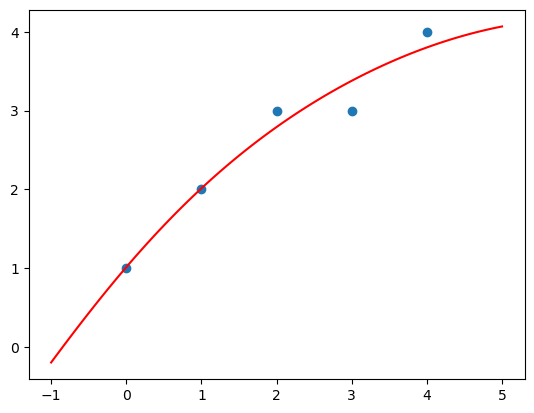

In [ ]:
model = GaussianRBFnetwork(d = 1, M = 5, alpha = 0.05, initialization = 'uniform')

X = np.array([[0], [1], [2], [3], [4]])
Y = np.array([1, 2, 3, 3, 4])

model.fit(X, Y, epochs = 15000, update = 5000, annealing = False)

# predict the outputs
predictions = model.predict(X)

# compute the training and test mean absolute error
trainError = mean_absolute_error(Y, predictions)

# return quality metrics
print('The mean absolute error on the training set is', trainError)

xModel = np.linspace(X[0] - 1, X[-1] + 1, 100)
yModel = model.predict(xModel)

plt.scatter(X, Y)

plt.plot(xModel, yModel, 'r')

We get a nice fit here. Similar to kernel smoothing, a larger $M$ will result in smaller loss, but may not generalize well. Further, there is an intermediate value of the learning rate $\alpha$ that will be most effective--too large and it will not find a good minimum, too small and it will take too long to converge.

If we run the code multiple times, we will usually land in different local minima due to the random initialization and existence of multiple local minima where gradient descent can get stuck.

### Example: Shampoo Dataset

In [ ]:
# read the shampoo sales dataset
data = pd.read_csv('../data/shampoo.csv')

# save the targets
Y = data['Sales'].to_numpy()

# make a column vector of 0s with n elements
X = np.zeros([Y.shape[0], 1])

# convert the vector to (0, 1, 2, ..., n)
X[:,0] = [i for i in range(Y.shape[0])]

#X = scale(X)

# split the data into train and test sets
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25, random_state = 1)

Epoch 0 	Loss = 142013.1495160939
Epoch 1000 	Loss = 14708.315135236666
Epoch 2000 	Loss = 11988.217154812224
Epoch 3000 	Loss = 10425.104332065093
Epoch 4000 	Loss = 9350.797541077636
Epoch 5000 	Loss = 9245.25884501607
Epoch 6000 	Loss = 8767.688297829127
Epoch 7000 	Loss = 8462.303497747187
Epoch 8000 	Loss = 10148.982038854254
Epoch 9000 	Loss = 8665.105720829455
The r^2 score is 0.685578691159587
The mean absolute error on the training set is 62.27225175998699
The mean absolute error on the testing set is 52.883149792376564


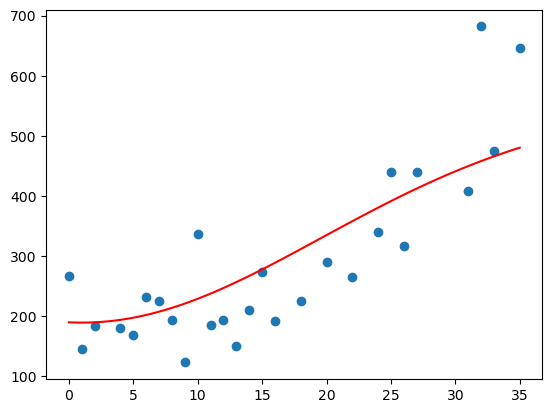

In [ ]:
model = GaussianRBFnetwork(d = 1, M = 20, alpha = 0.01)

model.fit(trainX, trainY, epochs = 10000, update = 1000, annealing = False)

# predict the outputs
trainPredictions = model.predict(trainX)

# plot the training points
plt.scatter(trainX, trainY, label = 'Training Data')

# plot the fitted model with the training data
xModel = np.atleast_2d(np.linspace(X[0][0],X[-1][0],100)).T

# compute the predicted curve
yModel = model.predict(xModel)

plt.plot(xModel, yModel, 'r')

testPredictions = model.predict(testX)

# compute the training and test mean absolute error
trainError = mean_absolute_error(trainY, trainPredictions)
testError = mean_absolute_error(testY, testPredictions)
    
# return quality metrics
print('The r^2 score is', r2_score(trainY, trainPredictions))
print('The mean absolute error on the training set is', trainError)
print('The mean absolute error on the testing set is', testError)

Again, a nice curved plot to fit the data.